In [1]:
# -*- coding: utf-8 -*-
"""
Constants, limit dates and time conversion functions.
"""

import numpy as np
import gsw
from datetime import datetime, timedelta

# rho = 1027 # density of seawater in kg/m^3
# cp = 3850  # specific heat capacity of seawater in J/kg/ºC
# better to use gsw functions to calculate density and heat capacity. 
# gsw functions allow to use an temperature, and salinity arrays
# given in each case for a vertical profile

# defining date conversion functions because our date format comes from Matlab

def num2date(dn):

    """
    Function that converts matlab datenum to dates. Although it's called
    like matplotlib.dates function, it is a different one.

    Args:
    - matlab datenum (float)

    Returns:
    - string containing date in yyyymmdd format

    """

    dt = datetime.fromordinal(int(dn) - 366)

    # checking if there's a day fraction
    frac = dn % 1

    if frac:
        dt += timedelta(days=frac)

    dt = str(dt)

    yr = dt[:4]
    mth = dt[5:7]
    day = dt[8:10]

    return f"{yr}-{mth}-{day}"

def date2num(year,month,day):

    """
    Function that converts matlab datenum to dates. Although it's called
    like matplotlib.dates function, it is a different one.

    Args:
    - year (int): yyyy
    - month (int) : m (no zeros to the left)
    - day (int): d (no zeros to the left)

    Returns:
    - numeric date (int)

    """

    dt = datetime(year, month, day)
    dn = dt.toordinal() + 366

    return dn


# the next lines are a function for generating plot xticks, because
# our dates are in matlab format so matplotlib.dates functions
# do not work properly

def set_xticks(date1, date2):

    """
    Function for creating equally spaced xticks for different time intervals
    
    date1: start of time period (in numeric format)
    date2: end of time period (in numeric format)
    """
    
    xticks = []

    for i in range(int(date1),int(date2+1)):

        if num2date(i)[5:10] == "01-01":
            xticks.append(i)
    
    return xticks
            


def safe_nanmean(arr):

    """
    function that prevents warning: 
    "RuntimeWarning: Mean of empty slice"

    Args:
    - arr: array that will be the object of np.nanmean function
    
    Returns: 
    - np.nanmean(arr) when it's confirmed that array is not empty or all nan
    - np.nan when array is all NaN or 0 size
    """

    if np.array(arr).size == 0 or np.all(np.isnan(arr)):
        return np.nan
    return np.nanmean(arr)

In [10]:
# LOADING DATA FROM FILES

# -*- coding: utf-8 -*-
"""
Loading data from various files; routes are hardcoded in the script. 
The files are .mat and .nc files, containing data from different sources 
(NCEP-NCAR reanalysis, AGL buoy, station 7, Cudillero advection module, etc.)
"""

import scipy.io
import numpy as np
import matplotlib.dates
from netCDF4 import Dataset

# -----------------------------------------------------------------------------------------------
# Components_Qo_From_NCEP.mat · old air-sea fluxes from reanalysis 

Qo_file = scipy.io.loadmat('data/Components_Qo_From_NCEP.mat')

Qo_dates = Qo_file['dates'][:,0]  # (23367,)
Hl_data = Qo_file['Hl'][:,0]      # (23367,)
Hs_data = Qo_file['Hs'][:,0]      # (23367,)
Qo_data = Qo_file['Qo'][:,0]      # (23367,)
swf_data = Qo_file['swf'][:,0]    # (23367,)
lwf_data = Qo_file['lwf'][:,0]    # (23367,)

print(f'old Qo data: {num2date(Qo_dates[0])} - {num2date(Qo_dates[-1])}')

# -----------------------------------------------------------------------------------------------
# AirSeaFluxes.mat (AGL) · atmospheric and hidrologic data from AGL buoy

fluxes_file = scipy.io.loadmat('data/AirSeaFluxes.mat')

fluxes_datet = fluxes_file['datet'][:,0]     # (124497,)
wind_speed = fluxes_file['wind_speed'][:,0]  # (124497,)
wind_dir = fluxes_file['wind_dir'][:,0]      # (124497,)
air_pr = fluxes_file['air_pr'][:,0]          # (124497,)
air_tem = fluxes_file['air_tem'][:,0]        # (124497,)
hum = fluxes_file['hum'][:,0]                # (124497,)
sea_tem = fluxes_file['sea_tem'][:,0]        # (124497,)
salt = fluxes_file['salt'][:,0]              # (124497,)

datefluxes1 = num2date(fluxes_datet[0])
datefluxes2 = num2date(fluxes_datet[-1])
print(f'AGL data: {datefluxes1} - {datefluxes2}')

firstjanfluxes = set_xticks(fluxes_datet[0], fluxes_datet[-1])

# -----------------------------------------------------------------------------------------------
# Station7.mat · station 7 data (temperature, salinity and pressure profiles)

station7_file = scipy.io.loadmat('data/station7.mat')

station_dates = station7_file['dates'][:,0]  # (279,)
pars = station7_file['pars']                 # (2669,279)
pres = station7_file['pres'][:,0]            # (2669,)
sals = station7_file['sals']                 # (2669,279)
tems = station7_file['tems']                 # (2669,279)

print(f'Station 7 data: {num2date(station_dates[0])} - {num2date(station_dates[-1])}')

firstjan24 = set_xticks(station_dates[0], station_dates[-1])

# -----------------------------------------------------------------------------------------------
# station7_MLD_stratif.mat · computed MLD, using algorithm from González-Pola et al. (2007)

station7_MLD_file = scipy.io.loadmat('data/station7_MLD_stratif.mat')

mld_depth = station7_MLD_file['D_all'][:,0]  # (279,)

# -----------------------------------------------------------------------------------------------
# Monthly_Resultant_Current · sea-current data for Cudillero advection module

MRC_file = scipy.io.loadmat('data/Monthly_Resultant_Current.mat')

MRC_data = MRC_file['data']      # (151,5)
compcorr = MRC_file['compcorr']  # (151,2)
date_MRC = MRC_file['date_sst'][:,0]

print(f'Cudillero advection (sea current data): {num2date(date_MRC[0])} - {num2date(date_MRC[-1])}')

# -----------------------------------------------------------------------------------------------
# Datos_Sant_Cudill · temperature data for Cudillero advection module

data_Sant_Cud = scipy.io.loadmat('data/Datos_Sant_Cudill.mat')

T_int_Cud = data_Sant_Cud['T_int_Cud'][:,0]
T_int_Sant = data_Sant_Cud['T_int_Sant'][:,0]
dates_mld = data_Sant_Cud['dates_mld'][:,0]
dates_Sant = data_Sant_Cud['dates_Sant'][0,:]
dates_Cud = data_Sant_Cud['dates_Cudill'][0,:]

print(f'Cudillero module mld data: {num2date(dates_mld[0])} - {num2date(dates_mld[-1])}')
print(f'Santander T data: {num2date(dates_Sant[0])} - {num2date(dates_Sant[-1])}')
print(f'Cudillero T data: {num2date(dates_Cud[0])} - {num2date(dates_Cud[-1])}')

# -----------------------------------------------------------------------------------------------
# updated NCEP-NCAR Reanalysis data (air-sea interaction fluxes)

ncep_dir = 'data/NCEP_NCAR complete series/'

archivo_DLWRF = Dataset(ncep_dir + 'downward_longwave_rad.nc', 'r')
archivo_DSWRF = Dataset(ncep_dir + 'downward_solar_rad_def.nc', 'r')
archivo_ULWRF = Dataset(ncep_dir + 'upward_longwave_rad.nc', 'r')
archivo_USWRF = Dataset(ncep_dir + 'upward_solar_rad.nc', 'r')
archivo_SHTFL = Dataset(ncep_dir + 'sensible_heat_net.nc', 'r')
archivo_LHTFL = Dataset(ncep_dir + 'latent_heat_net.nc', 'r')

time = archivo_DLWRF.variables['time'][:]
time = time/24 + date2num(1800,1,1)

dlwrf = archivo_DLWRF.variables['dlwrf'][:]
dswrf = archivo_DSWRF.variables['dswrf'][:]
ulwrf = archivo_ULWRF.variables['ulwrf'][:]
uswrf = archivo_USWRF.variables['uswrf'][:]
shtfl = archivo_SHTFL.variables['shtfl'][:]
lhtfl = archivo_LHTFL.variables['lhtfl'][:]

DLWRF = dlwrf[:,1,3]
DSWRF = dswrf[:,1,3]
ULWRF = ulwrf[:,1,3]
USWRF = uswrf[:,1,3]
SHTFL = shtfl[:,1,3]
LHTFL = lhtfl[:,1,3]

nlwrf = DLWRF - ULWRF
nswrf = DSWRF - USWRF
netflux = nswrf + nlwrf - SHTFL - LHTFL

# -----------------------------------------------------------------------------------------------
# SST and AVISO velocity data

datos_sst = scipy.io.loadmat('data/Datos_sst.mat')

sst_dates = datos_sst['Dates'][:,0]
sst_lon = datos_sst['lon'][:,0]
sst_lat = datos_sst['lat'][:,0]
sst_data = datos_sst['sst']

velocidades = scipy.io.loadmat('data/Datos_velocidad_aviso.mat')

vel_dates = velocidades['Dates'][:,0]
uga = velocidades['uga'][:,0]

date_ini = date2num(1995,1,1)
date_fin = date2num(2021,12,31)

firstjan21 = set_xticks(date_ini, date_fin)

print(f'NOAA SST data: {num2date(sst_dates[0])} - {num2date(sst_dates[-1])}')
print(f'AVISO velocity data: {num2date(vel_dates[0])} - {num2date(vel_dates[-1])}')

inicio_adv = np.argmin(np.abs(sst_dates - date_ini))

# -----------------------------------------------------------------------------------------------
# Matlab reference results (for comparison with Python modules)

resultados_adv = scipy.io.loadmat('data/resultados_adv.mat')
datesadv_mat = resultados_adv['Dates'][:,0]
qadv_mat = resultados_adv['Qadv'][:,0]

Qmix_mat = np.loadtxt('data/Qmix_mat.txt', skiprows=2)
q_pen_mat = np.loadtxt('data/q_pen.txt', skiprows=2)

# ------------------------------------------------------------------------------------------------
CSV_FILE = 'data\dTint_dt_results(9524).csv'

old Qo data: 1995-01-01 - 2010-12-31
AGL data: 2007-07-01 - 2021-09-12
Station 7 data: 1994-08-12 - 2024-10-21
Cudillero advection (sea current data): 1981-12-15 - 2009-12-15
Cudillero module mld data: 1994-08-12 - 2009-02-16
Santander T data: 1994-08-12 - 2010-11-24
Cudillero T data: 1993-05-13 - 2008-06-12
NOAA SST data: 1994-12-31 - 2021-12-30
AVISO velocity data: 1993-02-15 - 2021-07-15


In [4]:
# WIND COMPONENTS FUNCTION

def CalculaCompon(wind_dir, wind_speed):

    """
    Function for calculating wind components from wind speed and direction.

    Args: 
        wind_dir: wind directions (124497,) [º of deviation from north?]
        wind_speed: wind speeds (124497,) [m/s]

    Returns:
        compvto: components of wind velocity (124497x2) ([m/s],[m/s])
    """

    import numpy as np

    # create an array with the right dimensions to store wind components
    compvto = np.zeros((len(wind_speed),2))

    # wind components are [v*sin(theta), v*cos(theta)]
    compvto[:,0] = wind_speed*np.sin(wind_dir*np.pi/180)
    compvto[:,1] = wind_speed*np.cos(wind_dir*np.pi/180)


    return compvto

C:\Users\Asus\AppData\Local\Temp\ipykernel_24008\1956561763.py:212: RuntimeWarning: invalid value encountered in power
  Ws = U_star * (-CVB_depth / (kappa * L))**onethird


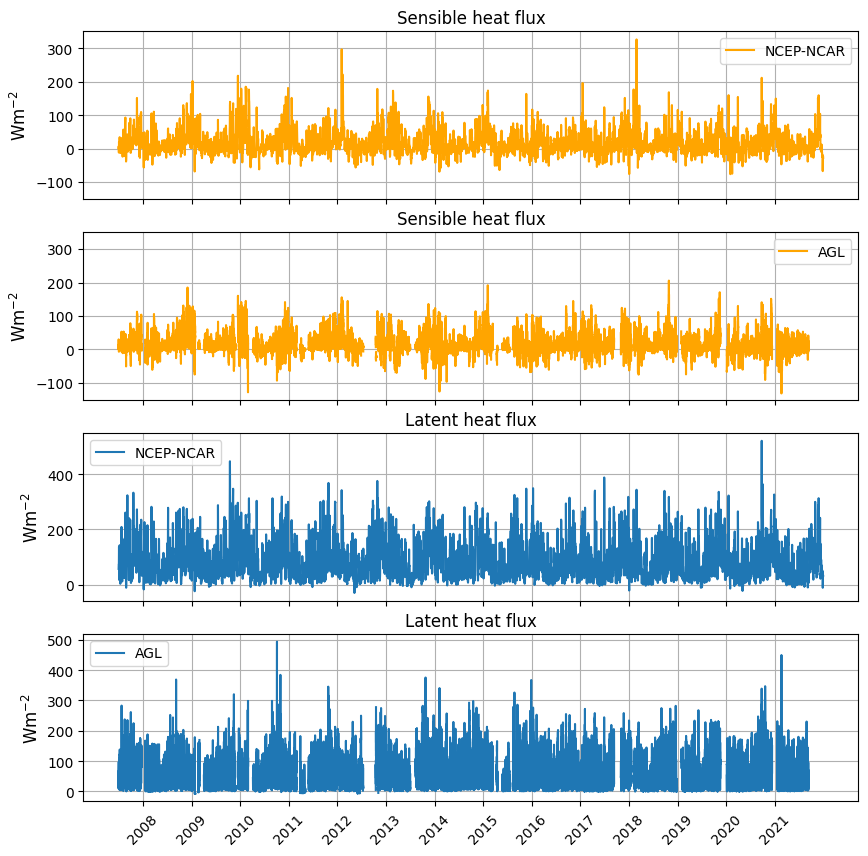

In [6]:
# AIR-SEA FLUXES FUNCTION - CALCULATING AIR-SEA HEAT FLUXES IN W/m^2 FROM AGL BUOY DATA
# AND COMPARING IT WITH NCEP-NCAR SERIES

def fluxes(ur, compvto, zr, Ta, zt, rh, zq, Ts, Pa):
    """
    Adapted from matlab air-sea toolbox:
    https://github.com/sea-mat/air-sea/blob/master/hfbulktc.m

    This function calculates sensible and latent heat fluxes following Edson and Fairall
    algorithm using data from AGL BUOY
    
    % Code follows Edson and Fairall TOGA COARE code (version 2.0), modified 
    % to include Rogers' weighting factor for unstable conditions.  Code does
    % include gustiness, and assumes that the marine boundary layer height is
    % known and constant over time for simiplicity. zr/L is limited to 
    % be <=3.0 to ensure that the code converges to nonzero stress and heat 
    % flux values for strongly stable conditions.  The bulk Richardson number
    % is computed between the sea surface and zr as a diagnostic about whether
    % turbulent boundary layer theory is applicable.  Code does not include 
    % warm layer effects to modify Ts.  See Fairall et al (1996), J. Geophys. 
    % Res., 101, 3747-3764, for description of full TOGA COARE code and 
    % comparison with data. 

    Args: 
        ur:             : wind speed (124497,) [m/s]
        compvto         : components of wind speed (124497x2) [m/s]
        zr              : wind speed measuring height [m]
        Ta              : air temperature [ºC]
        zt              : air temperature measuring height [m]
        rh              : relative humidity [%]
        zq              : relative humidity measuring height [m]
        Ts              : sea temperature [ºC]
        Pa              : air pressure [hPa]
    
    Returns:
        Hs     : sensible heat flux INTO ocean [W/m^2]
        Hl     : latent heat flux INTO ocean [W/m^2]
        stress : wind stress [N/m^2]
        tx, ty : zonal / meridional stress components [N/m^2]
    """
    from functions_for_fluxes import psiutc, psittc, LKB 
    from atmosphere import visc_air, qsat
    from windstress import cdn as cdntc
    from constants import kappa, g, Charnock_alpha, R_roughness

    # ------------------------------------------------------------------
    # Constants (from as_consts.m and inline definitions)
    # ------------------------------------------------------------------
    
    # heat capacity of air [J/kg/K]
    cp_air = 1004.7

    # saturation specific humidity coefficient reduced 2 % over salt water
    Qsat_coeff = 0.98

    # minimum gustiness (i.e. unresolved fluctuations) [m/s]
    min_gustiness = 0.5

    # conversion from [ºC] to [K]
    CtoK = 273.16

    # molecular weight ratio (water/air)
    eps_air = 0.62197

    # acceleration due to gravity [m/s^2]
    g = 9.8

    # gas constant for dry air [J/kg/K]
    gas_const_R = 287.04

    # Von Karman's meteorological constant 
    kappa = 0.4

    # depth of convective boundary layer in atmosphere [m]
    CVB_depth = 600 

    # scaling constant for gustiness
    beta_conv = 1.25

    # tolerance on Re changes to make sure solution has converged
    tol = 1e-3
    onethird = 1.0 / 3.0

    # moisture correction for temperature
    o61 = 1.0 / eps_air - 1.0

    # ------------------------------------------------------------------
    # Ensure 1D arrays
    # ------------------------------------------------------------------
    ur = np.asarray(ur).squeeze()
    Ta = np.asarray(Ta).squeeze()
    rh = np.asarray(rh).squeeze()
    Ts = np.asarray(Ts).squeeze()
    Pa = np.asarray(Pa).squeeze()
    zr = np.asarray(zr).squeeze()
    zt = np.asarray(zt).squeeze()
    zq = np.asarray(zq).squeeze()

    M = ur.size

    # Broadcast scalars
    if Pa.size == 1:
        Pa = np.full(M, Pa)
    if zr.size == 1:
        zr = np.full(M, zr)
    if zt.size == 1:
        zt = np.full(M, zt)
    if zq.size == 1:
        zq = np.full(M, zq)

    # ------------------------------------------------------------------
    # Atmospheric state variables
    # ------------------------------------------------------------------
    
    # compute the kinematic viscosity of dry air as a function of air temperature
    visc = visc_air(Ta)

    # compute saturation specific humididty q (kg/kg) from air temp [ºC] and air pressure [mbar]
    q = qsat(Ta,Pa)    

    # reducing saturation specific humidity
    Qsats = Qsat_coeff * q

    # calculating specific humidity 
    Q = 0.01 * rh * q

    # converting temperature to K
    T = Ta + CtoK

    # computing virtual temperature [K]
    Tv = T * (1 + o61 * Q)

    # computing air density [kg/m^3]
    rho = (100 * Pa) / (gas_const_R * Tv)

    # computing adiabatic temperature [ºC]
    Dt = (Ta + 0.0098 * zt) - Ts

    # calculating humidity difference to saturation
    Dq = Q - Qsats

    # ------------------------------------------------------------------
    # Initial neutral guess: compute initial neutral scaling coefficients
    # ------------------------------------------------------------------
    S = np.sqrt(ur**2 + min_gustiness**2)
    
    # Smith's neutral cd as first guess
    cdnhf = np.sqrt(cdntc(S,zr,drag='smith',Ta=air_tem)[0])

    z0t = 7.5e-5
    ctnhf = kappa / np.log(zt / z0t)

    z0q = z0t
    cqnhf = kappa / np.log(zq / z0q)

    U_star = cdnhf * S      # U_star = velocity friction scale [m/s]
    T_star = ctnhf * Dt     # T_star = temperature scale [ºC]
    Q_star = cqnhf * Dq     # Q_star = humidity scale [kg/kg]

    Dter = np.zeros(M)      # Dter = cool-skin temperature difference [ºC], positive if surface is cooler than bulk
    Dqer = np.zeros(M)      # Dqer = cool-skin humidity difference

    Reu = np.zeros(M)
    Ret = np.zeros(M)
    Req = np.zeros(M)

    # ------------------------------------------------------------------
    # Iteration loop
    # ------------------------------------------------------------------
    for _ in range(80):

        # save old values
        ReuO, RetO, ReqO = Reu.copy(), Ret.copy(), Req.copy()

        # compute Monin-Obukov length [m]
        bs = g * (T_star * (1 + o61 * Q) + o61 * T * Q_star) / Tv
        L = (U_star**2) / (kappa * bs)

        # set upper limit on zr/L = 3 to force convergence under very stable conditions
        idx = (L < zr / 3) & (L > 0)
        L[idx] = zr[idx] / 3

        zetu = zr / L
        zett = zt / L
        zetq = zq / L

        # surface roughness 
        z0 = (Charnock_alpha / g) * U_star**2 + R_roughness * visc / U_star

        # compute U_star correction for non-neutral conditions
        cdnhf = kappa / (np.log(zr / z0) - psiutc(zetu))
        U_star = cdnhf * S

        # roughness Reynolds #
        Reu = z0 * U_star / visc
        # compute other roughness Reynolds #s
        Ret, Req = LKB(Reu)

        # compute t and q roughness scales from roughness R#s
        z0t = visc * Ret / U_star
        z0q = visc * Req / U_star

        # compute new transfer coefficients at measurement heights
        cthf = kappa / (np.log(zt / z0t) - psittc(zett))
        cqhf = kappa / (np.log(zq / z0q) - psittc(zetq))

        # compute new values of T_star and Q_star
        T_star = cthf * (Dt + Dter)
        Q_star = cqhf * (Dq + Dqer)

        # estimate new gustiness
        Ws = U_star * (-CVB_depth / (kappa * L))**onethird
        wg = np.full(M, min_gustiness)

        # convection in unstable conditions only
        j = zetu < 0
        # set minimum gustiness
        wg[j] = np.maximum(min_gustiness, beta_conv * Ws[j])

        S = np.sqrt(ur**2 + wg**2)

    # ------------------------------------------------------------------
    # Convergence check
    # ------------------------------------------------------------------
    ii = (np.abs(Reu - ReuO) > tol) | (np.abs(Ret - RetO) > tol) | (np.abs(Req - ReqO) > tol)
    if np.any(ii):
        print(f"Algorithm did not converge for {ii.sum()} points")
        print("Indices:", np.where(ii)[0])

    # ------------------------------------------------------------------
    # Fluxes
    # ------------------------------------------------------------------

    # compute latent heat
    Le = (2.501 - 0.00237 * (Ts - Dter)) * 1e6

    # compute fluxes into ocean
    Hs = rho * cp_air * U_star * T_star
    Hl = rho * Le * U_star * Q_star

    # compute transfer coefficients at measurement heights 
    CD = (U_star / S)**2               # drag coefficient
    CT = U_star*T_star/(S*(Dt + Dter)) # Stanton number: temperature transfer coefficient
    CQ = U_star*Q_star/(S*(Dq + Dqer)) # Dalton number: moisture transfer coefficient

    # to compute mean stress, we don't want to include the effects
    # of gustiness which average out (in a vector sense)
    stress = rho * CD * S * ur
    tx = rho * CD * S * compvto[:, 0]
    ty = rho * CD * S * compvto[:, 1]

    # compute bulk Richardson number (as a diagnostic)
    RI = g*zr*(Dt + Dter + o61*T*(Dq + Dqer))/(Tv*S**2)

    # compute Webb correction to latent heat flux into ocean
    W = 1.61*U_star*Q_star + (1 + 1.61*Q)*U_star*T_star/T
    Hl_webb = rho*Le*W*Q

    return Hs, Hl, stress, tx, ty

if __name__ == "__main__":

    import csv
    import matplotlib.pyplot as plt

    zr, zt, zq = 2, 2, 2

    compvto = CalculaCompon(wind_dir, wind_speed)
    Hs, Hl, stress, tx, ty = fluxes(wind_speed, compvto, zr, air_tem, zt, hum, zq, sea_tem, air_pr)

    # Save Hs to CSV
    with open('Hs_results.csv', 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['date', 'Hs'])
        for date, hs_val in zip(fluxes_datet, Hs):
            writer.writerow([num2date(date), hs_val])


    # Save Hl to CSV
    with open('Hl_results.csv', 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['date', 'Hl'])
        for date, hl_val in zip(fluxes_datet, Hl):
            writer.writerow([num2date(date), hl_val])


    # start of datefluxes: 2007-07-01, end of datefluxes: 2021-09-12

    inicio_AGL = fluxes_datet[0]
    fin_AGL = fluxes_datet[-2]

    # fin_AGL = min(fin_AGL, time[-1])  # ensure we don't go beyond the NCEP data range

    lim1_ncep_idx = np.where(time == inicio_AGL)[0][0]
    lim2_ncep_idx = np.where(time == fin_AGL)[0]

    fig, axs = plt.subplots(4, figsize=(10,10), sharex=True)

    # plt.xticks(firstjanfluxes, [num2date(n) for n in firstjanfluxes], rotation=45)

    axs[0].plot(time[lim1_ncep_idx:], SHTFL[lim1_ncep_idx:],color = 'orange')
    axs[0].set_title('Sensible heat flux')
    axs[0].set_ylabel('Wm$^{-2}$',fontsize=12)
    # axs[0].set_xlabel('Time')
    axs[0].set_ylim(-150,350)
    axs[0].legend(['NCEP-NCAR'])
    axs[0].grid(True)

    axs[2].plot(time[lim1_ncep_idx:], LHTFL[lim1_ncep_idx:],)
    axs[2].set_title('Latent heat flux')
    axs[2].set_ylabel('Wm$^{-2}$',fontsize=12)
    # axs[1].set_xlabel('Time')
    axs[2].legend(['NCEP-NCAR'])
    axs[2].grid(True)

    axs[1].plot(fluxes_datet, -Hs, color = 'orange')
    axs[1].set_title('Sensible heat flux')
    axs[1].set_ylabel('Wm$^{-2}$',fontsize=12)
    # axs[2].set_xlabel('Time')
    axs[1].legend(['AGL'])
    axs[1].set_ylim(-150,350)
    axs[1].grid(True)

    axs[3].plot(fluxes_datet, -Hl)
    axs[3].set_title('Latent heat flux')
    # axs[3].set_xlabel('Time')
    axs[3].set_ylabel('Wm$^{-2}$',fontsize=12)
    axs[3].legend(['AGL'])
    axs[3].grid(True)

    for ax in axs[:-1]:
        ax.tick_params(labelbottom=False)

    firstjan_7_21 = set_xticks(int(inicio_AGL),time[-1])

    axs[-1].set_xticks(firstjan_7_21)
    axs[-1].set_xticklabels([num2date(n)[:4] for n in firstjan_7_21], rotation=45)

    for ax in axs:
        ax.grid(True)

    plt.show()

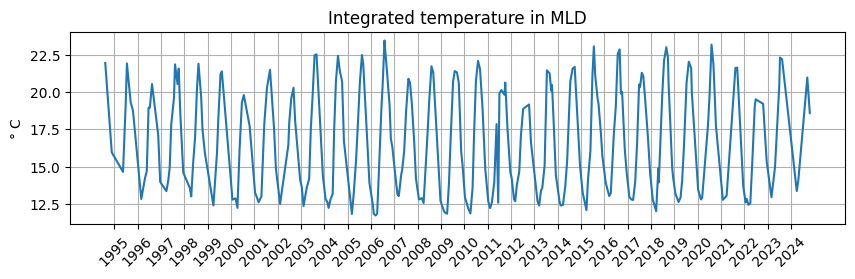

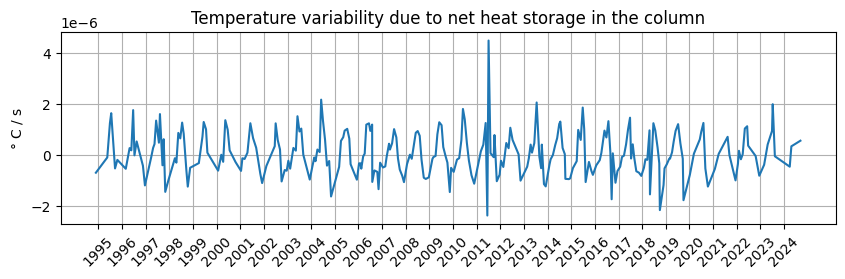

In [7]:
# QSTR CALCULATION - CALCULATING HEAT STORAGE IN THE COLUMN

def heat_storage_vscronin_isoterm(sals,tems,pres,mld,dates):

    """
    this function computes heat storaged in the column, which
    takes a part in the column's heat budget

    Args: 
    - sals: column's salinity profiles [psu]
    - tems: column's temperature profiles [ºC]
    - pres: column's pressure profile [mb]
    - mld: mixed layer depth array [m]
    - dates: dates corresponding to profiles

    Returns:

    - Tint: vertically integrated temperature
    - Tmix: MLD temperature taking entrainment into account
    - Qmix: entrainment heat flux temperature variability
    - Qstrg: column storaged heat variability

    --------------------------------------------------------

    Qstrg = d * cp * h * dTint/dt

    where

    d = reference layer density
    cp = seawater specific heat
    h = reference layer depth
    dTint/dt = time derivative of vertically integrated temperature

    Tint = 1/h * integ_0^h T * dz
    """

    import gsw

    # first date to consider, on to from which we want to compute fluxes
    n1 = date2num(1994,1,1)

    # find index corresponding to said date
    ii = np.where(dates>=n1) 
    # print(np.shape(ii)) = (1,279)

    # change to column vector
    i = np.transpose(ii)
    i = i[:,0]
    # print(np.shape(i)) = (279,)

    """
    if calculations were made taking an isobar as depth limit 
    reference, temperature would vary with time instead of depth h. 
    """ 

    # we look for MDL values and its corresponding densities for each profile (1 profile/date)
    h = np.full(len(i), np.nan) 
    den = np.full(len(i), np.nan)   

    # we want to calculate the temperature integrated in the column, Tint
    Tint = np.full(len(i), np.nan) 

    dTint = np.full(len(i), np.nan) 
    dt = np.full(len(i), np.nan)
    h_mean = np.full(len(i), np.nan)
    cp = np.full(len(i), np.nan)

    it1 = 0
    it2 = 0
    
    # for j in i:
    for j in range(len(i)): # recorro los índices de los índices de las fechas...

        # porque necesito unos nuevos índices j para montar mis T

        # for each profile in the time series, we need to acount for our column's depth limit
        it1 += 1

        z = np.ceil(mld[i[j]])        # mld[i[j]] is mixed layer depth for profile i 
        h[j] = z  
        den [j] = gsw.rho_t_exact(sals[int(z),i[j]], tems[int(z),i[j]], pres[int(z)])  # density at depth h


    for j in range(len(i)): # j va desde 0 hasta len(i)-1, lo que está bien porque así va de 0 a 278 y en total son 279 índices

        it2 += 1
        
        # integrated temperature: mean of every temperature value in the column
        Tint[j] = np.nanmean(tems[0:int(h[j])+1,i[j]])

        if j > 0 and j < len(i)-1: # para índices entre 1 y len(i)-1 (278)

            # dTint: variation of temperatures from one date to the previous one        
            dTint[j] = Tint[j] - Tint[j-1] 
            # time differential
            dt[j] = dates[i[j]] - dates[i[j-1]]
            # dt[j] = dt[j]*24*3600 # en s

            # averaged MLD from one date to the next
            h_mean[j] = np.mean(h[j-1:j+1]) 

            # averaged specific heat from one date to the next
            cp1 = gsw.cp_t_exact(sals[int(h[j-1]),i[j-1]], tems[int(h[j-1]),i[j-1]],h[j-1]) 
            cp2 = gsw.cp_t_exact(sals[int(h[j]),i[j]], tems[int(h[j]),i[j]], h[j])
            cp[j] = np.nanmean([cp1,cp2])

    Qstrg = dTint/(dt*24*3600)

    # Qmix[Qmix < 0] = 0
        
    return Tint, Qstrg

if __name__ == "__main__":

    # TINT
    fig = plt.figure(figsize=(10, 2.5))
    Tint = heat_storage_vscronin_isoterm(sals, tems, pres, mld_depth, station_dates)[0]
    plt.plot(station_dates, Tint)
    plt.xticks(firstjan24, [num2date(i)[:4] for i in firstjan24], rotation=45)
    plt.title("Integrated temperature in MLD")
    plt.ylabel("$\\degree$ C")
    plt.grid()
    
    # QSTRG
    fig = plt.figure(figsize=(10, 2.5))
    Qstrg = heat_storage_vscronin_isoterm(sals, tems, pres, mld_depth, station_dates)[1]
    plt.plot(station_dates, Qstrg)
    plt.xticks(firstjan24, [num2date(i)[:4] for i in firstjan24], rotation=45)
    plt.title("Temperature variability due to net heat storage in the column")
    plt.ylabel("$\\degree$ C / s")
    plt.grid()
    

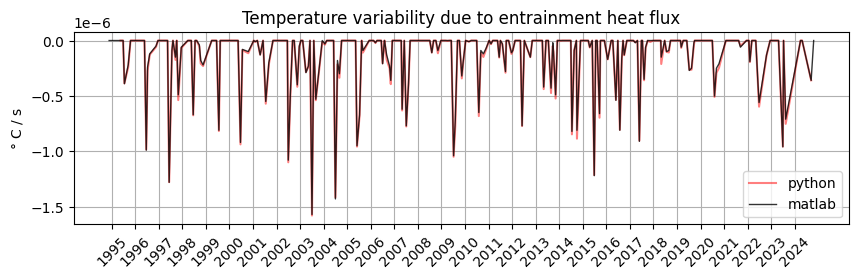

In [8]:
# ENTRAINMENT HEAT FLUX TEMPEARTURE VARIABILITY

def entrainment(sals,tems,pres,mld,dates):

    import gsw, numpy as np

    n1 = date2num(1994, 1, 1)
    ii = np.where(dates >= n1)[0]

    h = np.full(len(ii), np.nan)
    h_mean = np.full(len(ii), np.nan)
    den = np.full(len(ii), np.nan)
    Tint = np.full(len(ii), np.nan)
    Tmix = np.full(len(ii), np.nan)
    dTint = np.full(len(ii), np.nan)
    dt = np.full(len(ii), np.nan)
    ATint_mix = np.full(len(ii), np.nan)
    Qmix = np.full(len(ii), np.nan)

    for j in range(len(ii)):

        z = np.ceil(mld[ii[j]])
        h[ii[j]] = z
        den[ii[j]] = gsw.rho_t_exact(sals[int(z),ii[j]], tems[int(z),ii[j]], pres[int(z)])

    for j in range(len(ii)-1):

        Tint[ii[j]] = safe_nanmean(tems[0:int(h[ii[j]])+1,ii[j]])

        if j>=1:
            dTint[ii[j]] = Tint[ii[j]] - Tint[ii[j-1]]
            dt[ii[j]] = dates[ii[j]] - dates[ii[j-1]]
            h_mean[ii[j]] = safe_nanmean(h[ii[j-1]:ii[j]+1])

            cp1 = gsw.cp_t_exact(sals[int(h[ii[j-1]]),ii[j-1]], tems[int(h[ii[j-1]]),ii[j-1]], h[ii[j-1]])
            cp2 = gsw.cp_t_exact(sals[int(h[ii[j]]),ii[j]], tems[int(h[ii[j]]),ii[j]], h[ii[j]])
            cp = safe_nanmean([cp1,cp2])

            if h[ii[j]] > h[ii[j-1]]:

                Tmix[ii[j]] = safe_nanmean(tems[np.min([int(h[ii[j+1]]), int(h[ii[j]])]):np.max([int(h[ii[j+1]]), int(h[ii[j]])]),ii[j]])
            else:
                Tmix[ii[j]] = safe_nanmean(tems[np.min([int(h[ii[j+1]]), int(h[ii[j]])]):np.max([int(h[ii[j+1]]), int(h[ii[j]])]),ii[j]])


    dt = dt * 24 * 3600  # convert to seconds

    ATint_mix = (Tmix[:-1]-Tint[1:])/mld[1:]
    dh = np.diff(h)
    Qmix = np.where(dh > 0, ATint_mix * dh / dt[1:], 0.0)
    Qmix[Qmix>0] = 0

    Qmix[Qmix < -0.5e-5] = 0

    import numpy as np

    return Tmix, Qmix

if __name__ == "__main__":

    # TENT
    fig = plt.figure(figsize=(10, 2.5))
    Qmix = entrainment(sals, tems, pres, mld_depth, station_dates)[1]
    plt.plot(station_dates[1:], Qmix, 'r-', alpha=0.5, label='python')
    plt.plot(station_dates[1:], Qmix_mat, 'k-', linewidth=1, alpha=0.8, label='matlab')
    plt.xticks(firstjan24, [num2date(i)[:4] for i in firstjan24], rotation=45)
    plt.title("Qmix --improved code--")
    plt.title('Temperature variability due to entrainment heat flux')
    plt.ylabel('$\\degree$ C / s')
    plt.legend()
    plt.grid()


Slope: -2.242412e-26 ºC/s per day

=== DOMINANT FREQUENCIES ===
f =  0.992 cycles/year  | period ≈  1.01 years
f =  1.983 cycles/year  | period ≈  0.50 years
f =  3.967 cycles/year  | period ≈  0.25 years
f =  4.562 cycles/year  | period ≈  0.22 years
f =  5.653 cycles/year  | period ≈  0.18 years


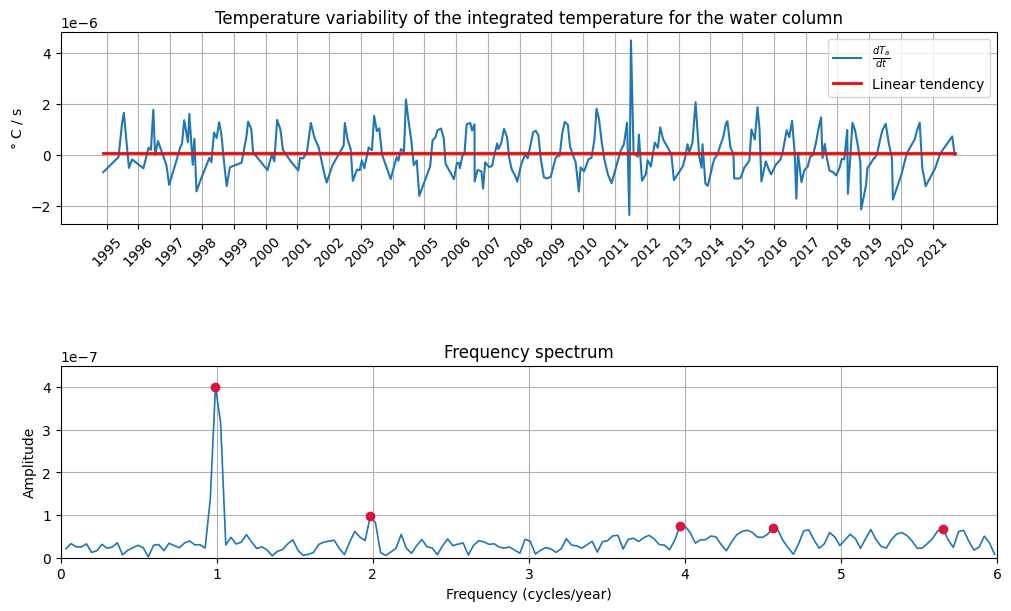

In [11]:
# QSTRG TEMPERATURE VARIABILITY TENDENCY

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from statsmodels.tsa.seasonal import STL

tendency_start = np.argmin(np.abs(station_dates - date_ini))
tendency_end = np.argmin(np.abs(station_dates - date_fin))

time_values = station_dates[tendency_start:tendency_end] 
dtemp_values = heat_storage_vscronin_isoterm(sals,tems,pres,mld_depth,station_dates)[1][tendency_start:tendency_end]

# NaNs filtering
mask = ~np.isnan(dtemp_values)
time_values_clean = time_values[mask]
dtemp_values_clean = dtemp_values[mask]

res = STL(dtemp_values_clean, period=365).fit()
trend_stl = res.trend

from statsmodels.tsa.seasonal import STL

slope, intercept, *_ = linregress(time_values_clean, trend_stl)

trend = slope * time_values_clean + intercept

print(f"Slope: {slope:.6e} ºC/s per day")

# ----------------------------------------------------------------------------------------
# CÁLCULO DEL ESPECTRO DE FOURIER

# -*- coding: utf-8 -*-
"""
Fourier analysis of irregular monthly temperature change rate (°C/s)
Robust version for date,value CSV files
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal

# =====================
# CONFIGURATION
# =====================
DATE_COL = "date"
VALUE_COL = "value"

TOP_K = 5
APPLY_DETREND = True
APPLY_WINDOW = True

# =====================
# SAFE READING
# =====================
df = pd.read_csv(CSV_FILE)

# Parsing dates
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
df[VALUE_COL] = pd.to_numeric(df[VALUE_COL], errors="coerce")

# Removing rows with NaN values in date or value columns
df = df.dropna(subset=[DATE_COL, VALUE_COL])

# Time sorting
df = df.sort_values(DATE_COL).set_index(DATE_COL)

# =====================
# CONVERSION TO REGULAR MONTHLY TIME SERIES
# =====================
# Monthly mean
df_monthly = df.resample("MS").mean()

# Time gap interpolation
df_monthly[VALUE_COL] = df_monthly[VALUE_COL].interpolate("time")

# Removing possible residual NaNs
df_monthly = df_monthly.dropna()

# =====================
# SERIE NUMÉRICA
# =====================
x = df_monthly[VALUE_COL].to_numpy()
n = x.size

if n < 24:
    raise ValueError("Series is too short for spectral analysis performance")

# =====================
# PREPROCESSING
# =====================
x_proc = x.copy()

# Removing mean and tendency
if APPLY_DETREND:
    x_proc = signal.detrend(x_proc, type="linear")

# Ventana de Hann
if APPLY_WINDOW:
    x_proc *= signal.windows.hann(n)

# =====================
# FFT
# =====================
fs = 1.0  # 1 muestra por mes
fft_vals = np.fft.rfft(x_proc)

freq_cpm = np.fft.rfftfreq(n, d=1/fs)   # ciclos/mes
freq_cpy = freq_cpm * 12.0              # ciclos/año

amplitude = 2 * np.abs(fft_vals) / n
power = np.abs(fft_vals)**2 / n

# removing 0 component
freq = freq_cpy[1:]
amp = amplitude[1:]

# =====================
# PEAK DETECTION
# =====================
peaks, props = signal.find_peaks(
    amp,
    height=np.percentile(amp, 75)
)

order = np.argsort(props["peak_heights"])[::-1]
peaks = peaks[order][:TOP_K]

dom_freqs = freq[peaks]
dom_amps = amp[peaks]

# =====================
# RESULTS
# =====================
print("\n=== DOMINANT FREQUENCIES ===")
for f, a in zip(dom_freqs, dom_amps):
    print(f"f = {f:6.3f} cycles/year  | period ≈ {1/f:5.2f} years")

# =====================
# GRAPHS
# =====================

fig, ax = plt.subplots(2, 1, figsize=(10, 6), constrained_layout=True)

# serie mensual
ax[0].plot(time_values_clean, dtemp_values_clean, label="$\\frac{dT_a}{dt}$")
ax[0].plot(time_values_clean, trend, 'r', linewidth=2, label="Linear tendency")
# ax[0].set_xlabel("Tiempo (años)")
ax[0].set_xticks(firstjan21)
ax[0].set_title("Temperature variability of the integrated temperature for the water column")
ax[0].set_xticklabels([num2date(n)[:4] for n in firstjan21], rotation=45)
ax[0].set_ylabel("$\\degree$ C / s")
ax[0].legend()
ax[0].grid(True)

# overlay point markers for dTint/dt data points
plt.plot(
    time_values_clean,
    dtemp_values_clean,
    '.', color='k', markersize=3, alpha=0.7
)

fig.get_layout_engine().set(hspace=0.25)

# Espectro
ax[1].plot(freq, amp, lw=1.2)
ax[1].scatter(dom_freqs, dom_amps, color="crimson", zorder=3)
ax[1].set_xlim(0, 6)
ax[1].set_ylim(0,4.5e-7)
ax[1].set_xlabel("Frequency (cycles/year)")
ax[1].set_ylabel("Amplitude")
ax[1].set_title("Frequency spectrum")
ax[1].grid(True)

plt.show()

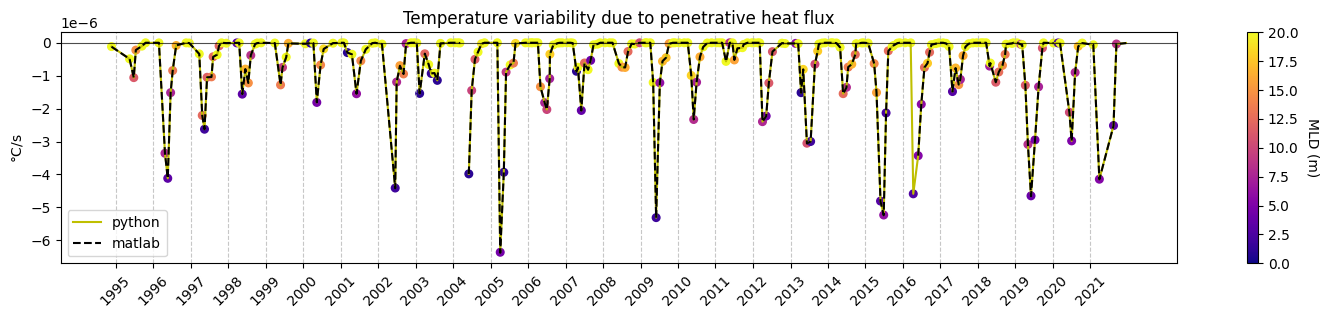

In [12]:
# PENETRATIVE HEAT FLUX CALCULATION

import numpy as np
import gsw

def calc_q_pen_mat(dates, mld, time, q0):
    """
    Function for computing Qpen

    Parameters
    ----------
    dates : (N,)
        dates for MLD profiles.
    mld : (N,)
        mixed layer depth
    time : (M,)
        sun radiation dates
    q0 : (M,)
        sun radiation heat flux
    """

    dens = []
    cp = []
    for i in range(len(dates)):

        dens.append(gsw.density.rho_t_exact(sals[int(mld[i]),i], tems[int(mld[i]),i], pres[int(mld[i])]))
        cp1 = gsw.cp_t_exact(sals[int(mld[i-1]),i-1], tems[int(mld[i-1]),i-1],mld[i-1]) 
        cp2 = gsw.cp_t_exact(sals[int(mld[i]),i], tems[int(mld[i]),i], mld[i])
        cp.append(safe_nanmean([cp1,cp2]))


    # optical parameters
    R = 0.62
    y1 = 0.60
    y2 = 20

    q_pen_flux = np.full((len(dates)-1), np.nan)
    q_pen = np.full((len(dates)-1), np.nan)

    for i in range(len(dates)-1):

        # --------------------------
        # q0 average
        # --------------------------
        mask = (time >= dates[i]) & (time < dates[i+1])

        if np.any(mask):
            q0_mean = safe_nanmean(q0[mask])
        else:
            q0_mean = np.nan

        # --------------------------
        # average MLD
        # --------------------------
        mld_act = safe_nanmean(mld[i:i+2])

        mld_i = int(np.round(mld[i]))
        mld_ip1 = int(np.round(mld[i+1]))

        # --------------------------
        # Average density
        # --------------------------
        den_act = safe_nanmean([
            safe_nanmean(dens[:mld_i+1]),
            safe_nanmean(dens[:mld_ip1+1])
        ])

        # --------------------------
        # Average Cp
        # --------------------------
        cp_act = safe_nanmean([
            safe_nanmean(cp[:mld_i+1]),
            safe_nanmean(cp[:mld_ip1+1])
        ])

        # --------------------------
        # Penetrative heat flux
        # --------------------------
        q_pen_flux[i] = q0_mean * (
            R*np.exp(-mld_act/y1)
            +
            (1-R)*np.exp(-mld_act/y2)
        )

        # ºC/s
        q_pen[i] = (
            q_pen_flux[i] /
            (den_act * cp_act * mld_act)
        )

        if q_pen[i] > 1e-5:
            q_pen[i] = np.nan

    return q_pen

if __name__ == "__main__":

    T_pen = -calc_q_pen_mat(station_dates, mld_depth, time, nswrf)

    end_date_21 = date2num(2021,12,14)
    end_date_21_idx = np.where(station_dates == end_date_21)[0][0]

    fig = plt.figure(figsize=(18,3))
    plt.plot(station_dates[:-1], T_pen, 'y-', label='python')
    plt.plot(station_dates[:-1], -np.array(q_pen_mat), 'k--', label='matlab')
    plt.scatter(station_dates[:end_date_21_idx], T_pen[:end_date_21_idx], c = mld_depth[:end_date_21_idx], cmap='plasma', edgecolor=None, vmin = 0, vmax = 20, s = 30)
    # place colorbar label more to the right so it doesn't overlap with colorbar ticks
    plt.colorbar().set_label('MLD (m)', rotation=270, labelpad=15)
    plt.ylabel('$\\degree$C/s')
    plt.title('Temperature variability due to penetrative heat flux')
    plt.xticks(firstjan21, [num2date(n)[:4] for n in firstjan21], rotation=45)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    # plot y = 0 axis
    plt.axhline(0, color='k', linewidth=0.8, alpha=0.7)
    plt.legend()
    plt.show()

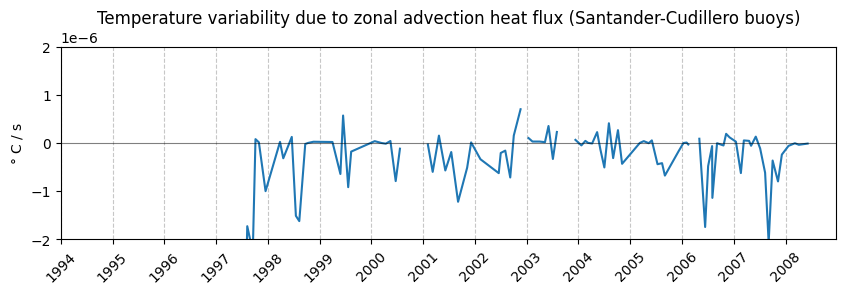

In [13]:
# CUDILLERO BUOY ADVECTION HEAT FLUX CALCULATION

def q_adv_sant_cud(dates_Qadv, dates_mld):

    """
    Computing advection heat flux based on advection between Santander and Cudillero buoys

    Args:
        dates_Qadv: dates from measured currents between the two buoys (151,)
        dates_mld: dates for Santander temperature profiles (127,)

    Returns:
        Q_adv_Sant_Cud: advection heat flux (127,) [W/m^2]
    """

    # distance between the two buoys in m
    Ax_Cudill_Sant = 218.56e3 

    Q_adv_Sant_Cud = np.zeros(len(dates_mld))
    # S_adv_Sant_Cud = np.zeros(len(dates_mld))

    # looping over every available Santander temperature profile date
    for i in range(len(dates_mld)):

        # no data for dates previous to 01/06/1997 (when Cudillero buoy started measurements)
        if dates_mld[i] <= date2num(1997,6,1):
            Q_adv_Sant_Cud[i] = np.nan
            # S_adv_Sant_Cud[i] = np.nan
            pass 

        # saving index 
        j = np.where(dates_Qadv >= dates_mld[i])[0] 

        if j[0] == 1:

            Q_adv_Sant_Cud[i] = 1e-2*compcorr[j[0],0]*((T_int_Cud[i] - T_int_Sant[i])/Ax_Cudill_Sant)
            # S_adv_Sant_Cud[i] = 1e-2*compcorr[j[0],0]*((S_int_Cud[i] - S_int_Sant[i])/Ax_Cudill_Sant)

        elif (dates_Qadv[j[0]] - dates_mld[i]) > (dates_mld[i] - dates_Qadv[j[0]-1]):

            Q_adv_Sant_Cud[i] = 1e-2*compcorr[j[0]-1,0]*((T_int_Cud[i] - T_int_Sant[i])/Ax_Cudill_Sant)
            # S_adv_Sant_Cud[i] = 1e-2*compcorr[j[0]-1,0]*((S_int_Cud[i] - S_int_Sant[i])/Ax_Cudill_Sant)

        elif (dates_Qadv[j[0]] - dates_mld[i]) <= (dates_mld[i] - dates_Qadv[j[0]-1]):

            Q_adv_Sant_Cud[i] = 1e-2*compcorr[j[0],0]*((T_int_Cud[i] - T_int_Sant[i])/Ax_Cudill_Sant)
            # S_adv_Sant_Cud[i] = 1e-2*compcorr[j[0],0]*((S_int_Cud[i] - S_int_Sant[i])/Ax_Cudill_Sant)

    return Q_adv_Sant_Cud

if __name__ == "__main__":

    import matplotlib.pyplot as plt

    year = MRC_data[:,0].astype(int)
    month = MRC_data[:,1].astype(int)
    day = MRC_data[:,2].astype(int)

    dates_Qadv = np.vectorize(date2num)(year, month, day)

    Q_adv_Sant_Cud = q_adv_sant_cud(dates_Qadv,dates_mld)

    fig = plt.figure(figsize=(10,2.5))
    plt.plot(dates_mld, -Q_adv_Sant_Cud)
    plt.ylim(-4e-6,4e-6)
    plt.axhline(y=0, color='k', linestyle='-', linewidth=0.8, alpha=0.5)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.ylim(-2e-6,2e-6)

    firstjan9 = np.array([date2num(y,1,1) for y in range(1994,2009)])

    plt.xticks(firstjan9, [num2date(n)[:4] for n in firstjan9], rotation=45)
    plt.title('Temperature variability due to zonal advection heat flux (Santander-Cudillero buoys)')
    # plt.xlabel('Dates')
    plt.ylabel('$\\degree$ C / s')
    plt.show()
    

Date range: 1993-02-15 to 2021-07-15
Qadv range: -2.842e-07 to 5.560e-07 ºC/s


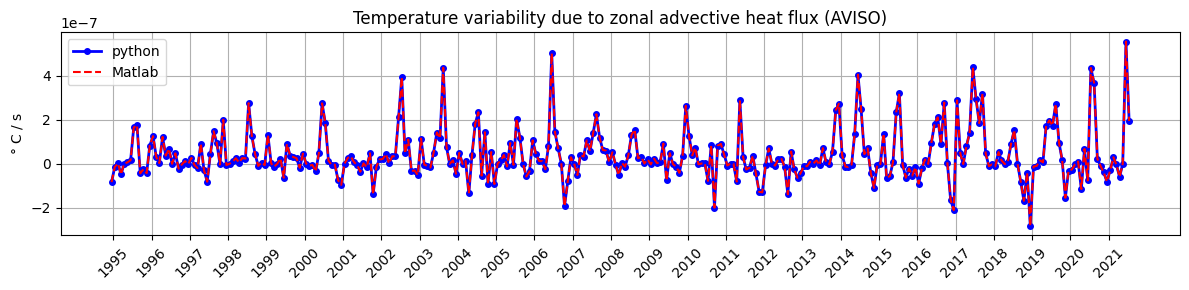

In [15]:
# AVISO ZONAL PENETRATIVE HEAT FLUX TEMPERATURE VARIABILITY

def calc_qadv_aviso(pos, year_start=1993, year_end=2021,
                    sst_file='data/Datos_sst.mat', vel_file='data/Datos_velocidad_aviso.mat'):
    """
    Computes zonal advective heat flux from SST gradients and AVISO surface currents.

    The idea is: if water is moving east (uga > 0), it brings SST from the west,
    so we use the west gradient. If it moves west (uga < 0), it brings SST from the east.

    Args:
        pos        : [lat, lon] of the point of interest
        year_start : first year of the monthly averaging loop (default 1993)
        year_end   : last year of the monthly averaging loop (default 2021)
        sst_file   : path to SST .mat file (default 'Datos_sst.mat')
        vel_file   : path to AVISO velocity .mat file (default 'Datos_velocidad_aviso.mat')

    Returns:
        Dates  : date array for AVISO data (MATLAB datenums)
        Qadv   : zonal advective temperature tendency [ºC/s], same length as Dates
    """

    # --- load SST data ---
    datos_sst = scipy.io.loadmat(sst_file)
    sst   = datos_sst['sst']
    lat   = datos_sst['lat'].squeeze()
    lon   = datos_sst['lon'].squeeze()
    dates = datos_sst['Dates'].squeeze()

    # --- find grid indices for the point of interest ---
    aa   = np.argmin(np.abs(lat - pos[0]))
    bb   = np.argmin(np.abs(lon - pos[1]))
    bb_e = np.argmin(np.abs(lon - (pos[1] + 1)))
    bb_w = np.argmin(np.abs(lon - (pos[1] - 1)))

    # SST at point and east/west SST anomalies
    sst_sats = sst[aa, bb, :]
    ASST_E   = sst[aa, bb_e, :] - sst_sats
    ASST_W   = sst[aa, bb_w, :] - sst_sats

    # --- monthly averages of SST gradients ---
    ASST_E_m = []
    ASST_W_m = []

    for y in range(year_start, year_end + 1):
        for m in range(1, 13):
            d_ini = date2num(y, m, 1)
            d_fin = date2num(y, m + 1, 1) if m < 12 else date2num(y + 1, 1, 1)
            idx = np.where((dates >= d_ini) & (dates < d_fin))[0]

            if len(idx) == 0:
                ASST_E_m.append(np.nan)
                ASST_W_m.append(np.nan)
            else:
                ASST_E_m.append(np.nanmean(ASST_E[idx]))
                ASST_W_m.append(np.nanmean(ASST_W[idx]))

    ASST_E_m = np.array(ASST_E_m)
    ASST_W_m = np.array(ASST_W_m)

    # --- load AVISO velocities ---
    datos_vel = scipy.io.loadmat(vel_file)
    uga   = datos_vel['uga'].squeeze()
    Dates = datos_vel['Dates'].squeeze()

    # skip first month and trim to match length of AVISO velocity vector
    # (monthly SST array starts one month before the velocity data)
    n = len(uga)
    ASST_E_m = ASST_E_m[1 : n + 1]
    ASST_W_m = ASST_W_m[1 : n + 1]

    # --- zonal distance between point and point±1º lon (meters) ---
    dist = gsw.distance([pos[1], pos[1] - 1], [pos[0], pos[0]])[0]

    # --- compute Qadv ---
    Qadv = np.zeros(n)

    neg     = uga < 0
    pos_idx = uga > 0

    Qadv[pos_idx] = np.abs(uga[pos_idx]) * ASST_W_m[pos_idx] / dist
    Qadv[neg]     = np.abs(uga[neg])     * ASST_E_m[neg]     / dist

    return Dates, Qadv


if __name__ == '__main__':

    pos = [43.8, -3.75]
    Dates, Qadv = calc_qadv_aviso(pos)

    print(f"Date range: {num2date(Dates[0])} to {num2date(Dates[-1])}")
    print(f"Qadv range: {np.nanmin(Qadv):.3e} to {np.nanmax(Qadv):.3e} ºC/s")

    fig, ax = plt.subplots(figsize=(12, 3))
    ax.plot(Dates, Qadv, 'o-', color='b', markersize=4,
            markerfacecolor='b', linewidth=2, label='python')
    ax.plot(datesadv_mat, qadv_mat, 'r--', label='Matlab')  # remove if no Matlab reference
    ax.set_title('Temperature variability due to zonal advective heat flux (AVISO)')
    ax.set_ylabel('$\\degree$ C / s')
    ax.set_xticks(firstjan21)
    ax.set_xticklabels([num2date(n)[:4] for n in firstjan21], rotation=45)
    ax.grid()
    ax.legend()
    plt.tight_layout()
    plt.show()